The dataset was used in the 1983 American Statistical Association Exposition. The data concerns city-cycle fuel consumption in miles per gallon, to be predicted in terms of 2 multivalued discrete and 4 continuous variables. 

Dataset: cars-dataset.csv

Attribute Information:

Car Name – Name of the car

Cyl – No of cylinders in the car – Multivalued discrete

Disp – Displacement – continuous

Hp – Horsepower – continuous

Wt – Weight – continuous

Acc – Acceleration – continuous

Yr – Model of the car – Multivalued discrete

Mpg - Miles per gallon - continuous

#  Launch a new python notebook and read the data set. EDA & Pre-processing (Make sure to remove all non-numeric entries from numeric columns) – 5 points 

In [46]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from sklearn.decomposition import PCA
from scipy.stats import zscore


In [30]:
df = pd.read_csv("cars-dataset(1).csv")  

In [31]:
df.head()

,car name,cyl,disp,hp,wt,acc,yr,mpg
0,chevrolet chevelle malibu,8,307.0,130,3504,12.0,70,18.0
1,buick skylark 320,8,350.0,165,3693,11.5,70,15.0
2,plymouth satellite,8,318.0,150,3436,11.0,70,18.0
3,amc rebel sst,8,304.0,150,3433,12.0,70,16.0
4,ford torino,8,302.0,140,3449,10.5,70,17.0


In [32]:
df.describe()

,cyl,disp,wt,acc,yr,mpg
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,5.454774,193.425879,2970.424623,15.568090,76.010050,23.514573
std,1.701004,104.269838,846.841774,2.757689,3.697627,7.815984
min,3.000000,68.000000,1613.000000,8.000000,70.000000,9.000000
25%,4.000000,104.250000,2223.750000,13.825000,73.000000,17.500000
50%,4.000000,148.500000,2803.500000,15.500000,76.000000,23.000000
75%,8.000000,262.000000,3608.000000,17.175000,79.000000,29.000000
max,8.000000,455.000000,5140.000000,24.800000,82.000000,46.600000


In [33]:
df.drop('car name', axis=1,inplace = True)

In [34]:
df.head()

,cyl,disp,hp,wt,acc,yr,mpg
0,8,307.0,130,3504,12.0,70,18.0
1,8,350.0,165,3693,11.5,70,15.0
2,8,318.0,150,3436,11.0,70,18.0
3,8,304.0,150,3433,12.0,70,16.0
4,8,302.0,140,3449,10.5,70,17.0


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
cyl     398 non-null int64
disp    398 non-null float64
hp      398 non-null object
wt      398 non-null int64
acc     398 non-null float64
yr      398 non-null int64
mpg     398 non-null float64
dtypes: float64(3), int64(3), object(1)
memory usage: 21.8+ KB


In [36]:
#On inspecting records we find "?" in the columns. Replace them with "nan"
#Replace them with nan and remove the records from the data frame that have "nan"
df = df.replace('?', np.nan)
df = df.apply(lambda x: x.fillna(x.median()),axis=0)

In [37]:
df['hp'] = df['hp'].astype('float64')

In [38]:
df['wt'] = df['wt'].astype('float64')

In [39]:
df['cyl'] = df['cyl'].astype('float64')

In [40]:
df['yr'] = df['yr'].astype('float64')

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
cyl     398 non-null float64
disp    398 non-null float64
hp      398 non-null float64
wt      398 non-null float64
acc     398 non-null float64
yr      398 non-null float64
mpg     398 non-null float64
dtypes: float64(7)
memory usage: 21.8 KB


# Use pair plot or scatter matrix to visualize how the different variables are related (Hint: The amount of Gaussian curves in the plot should give a visual identification of different clusters existing in the dataset) – 5 points

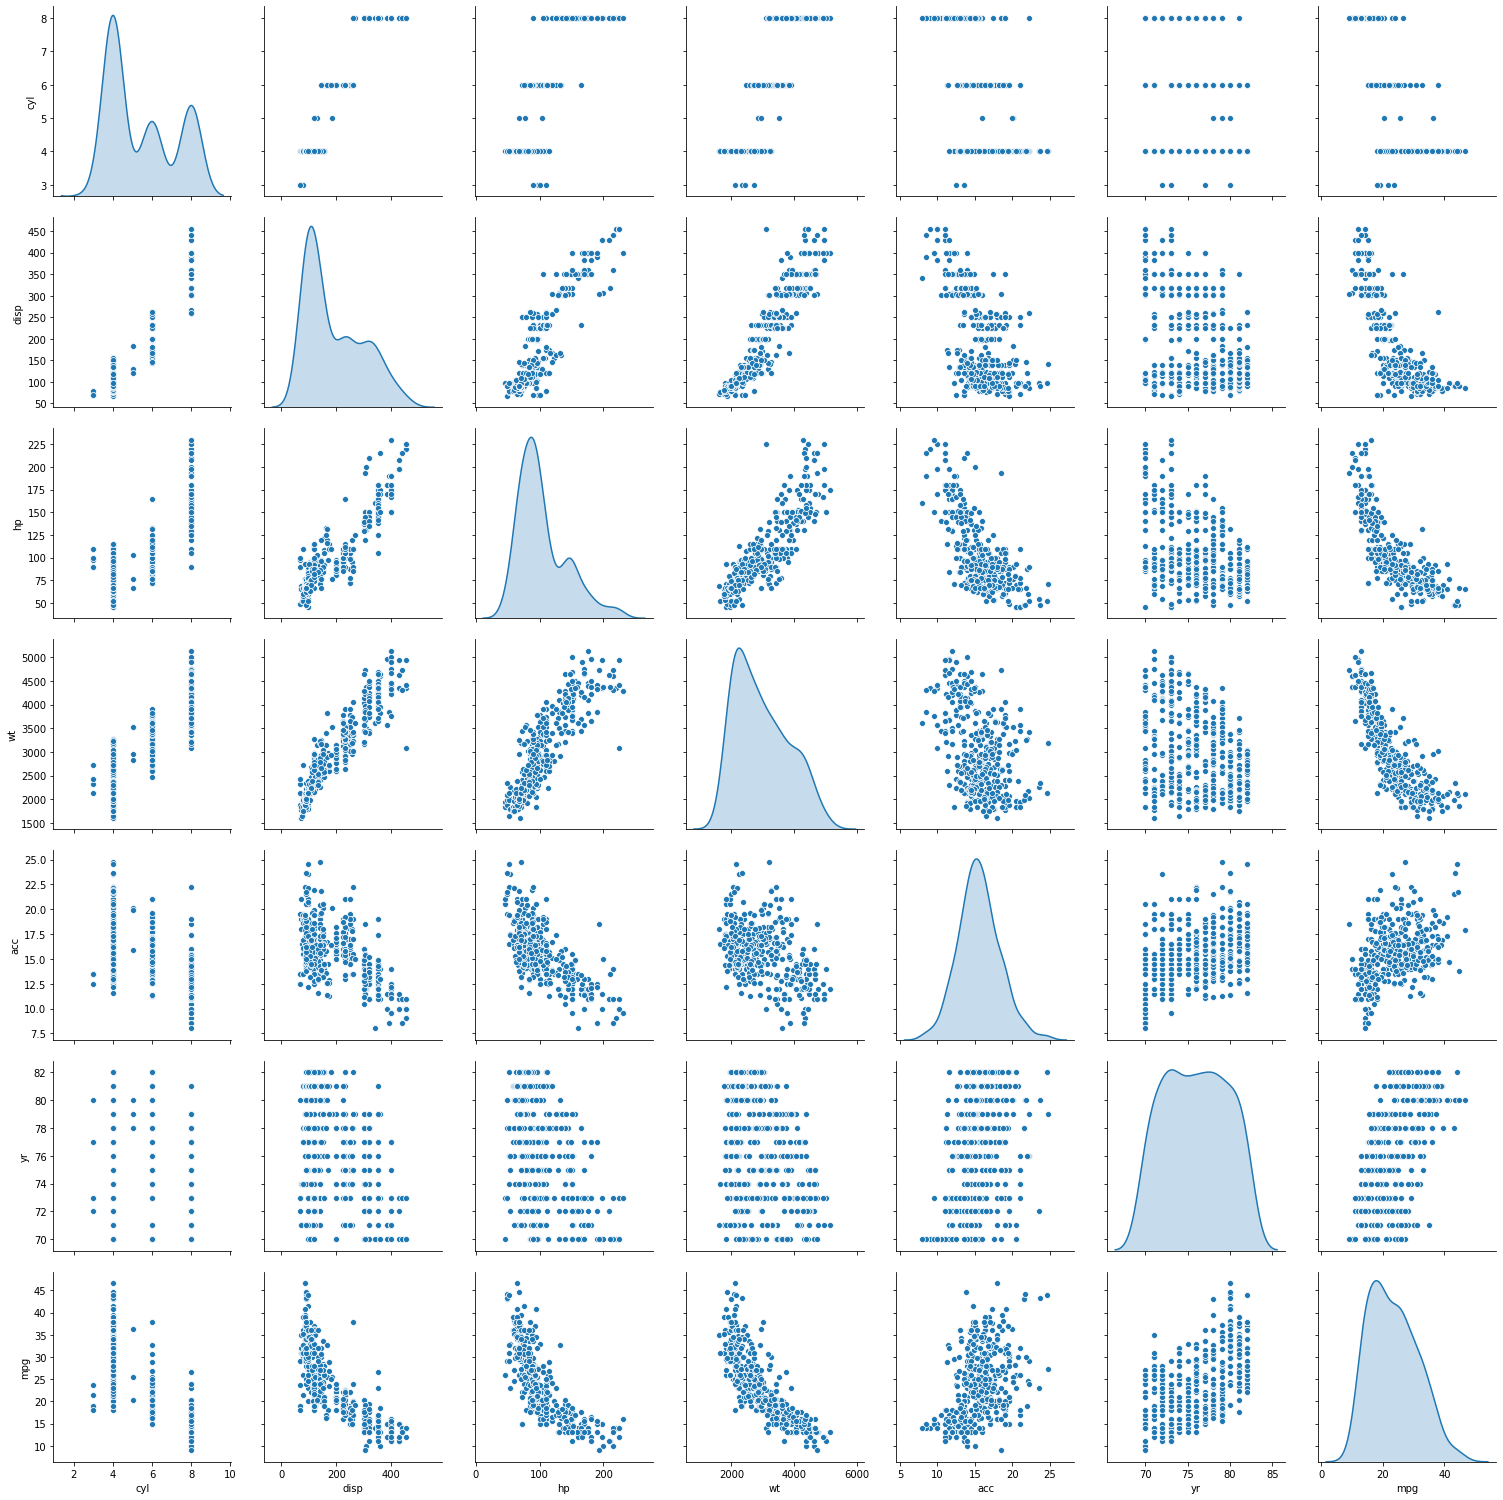

In [42]:
sns.pairplot(df, diag_kind='kde', size=3) 

Text(0.5, 1, 'Correlation Matrix')

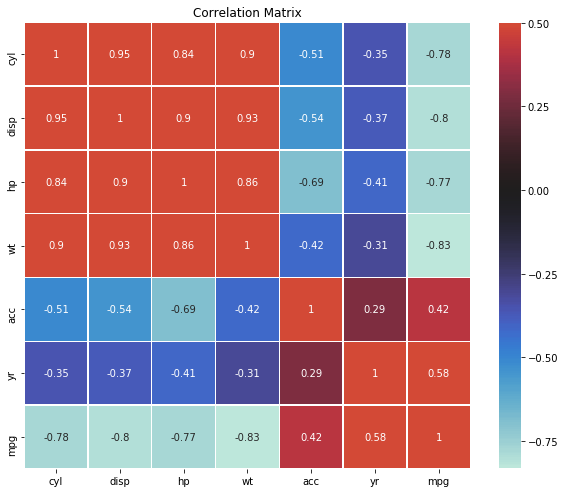

In [43]:
corr = df.corr()
plt.figure(figsize=(10, 10))
sns.heatmap(corr,annot=True, xticklabels=corr.columns.values, yticklabels=corr.columns.values, vmax=.5, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .82})
plt.title('Correlation Matrix')

Observations are below

1. There is high correlation between hp and disp i.e 0.95
2. There is high correlation between hp and Cycl i.e 0.84
3. There is high correlation between wt and Cycl i.e 0.9
4. There is high correlation between wt and disc i.e 0.93
5. There is high correlation between hp and dips i.e 0.9
6. There is high correlation between wt and hp i.e 0.86
8. There is high correlation between hp and wt i.e 0.86


In [44]:
X = df.drop("mpg", axis=1)
Y = df["mpg"] 

In [27]:
from scipy.stats import zscore
X = X.apply(zscore)

In [47]:
# We transform (centralize) the entire X (independent variable data) to zscores through transformation. We will create the PCA dimensions
# on this distribution. 
sc = StandardScaler()
X_std =  sc.fit_transform(X)          
cov_matrix = np.cov(X_std.T)
print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s [[ 1.00251889  0.95311615  0.84340357  0.89827376 -0.50669259 -0.34962425]
 [ 0.95311615  1.00251889  0.89803457  0.93517383 -0.54505356 -0.37109656]
 [ 0.84340357  0.89803457  1.00251889  0.86461476 -0.68831918 -0.41477495]
 [ 0.89827376  0.93517383  0.86461476  1.00251889 -0.41850885 -0.30733654]
 [-0.50669259 -0.54505356 -0.68831918 -0.41850885  1.00251889  0.28886274]
 [-0.34962425 -0.37109656 -0.41477495 -0.30733654  0.28886274  1.00251889]]


In [48]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eigenvectors)
print('\n Eigen Values \n%s', eigenvalues)

Eigen Vectors 
%s [[-0.45509041 -0.18276349  0.17104591  0.65709523 -0.46420823  0.28804531]
 [-0.46913807 -0.16077095  0.13443134  0.18742114  0.83717483 -0.00141408]
 [-0.46318283 -0.0139189  -0.12440857 -0.62819714 -0.10059817  0.60418441]
 [-0.44618821 -0.25676595  0.27156481 -0.33868744 -0.26829299 -0.68887559]
 [ 0.32466834 -0.21039209  0.86752316 -0.15214558  0.0367486   0.27061128]
 [ 0.23188446 -0.9112425  -0.33294164 -0.02469974  0.01405118  0.06487726]]

 Eigen Values 
%s [4.26378678 0.84068225 0.67499578 0.13552589 0.03625731 0.06386533]


In [49]:
# Step 3 (continued): Sort eigenvalues in descending order

# Make a set of (eigenvalue, eigenvector) pairs
eig_pairs = [(eigenvalues[index], eigenvectors[:,index]) for index in range(len(eigenvalues))]

# Sort the (eigenvalue, eigenvector) pairs from highest to lowest with respect to eigenvalue
eig_pairs.sort()

eig_pairs.reverse()
print(eig_pairs)

# Extract the descending ordered eigenvalues and eigenvectors
eigvalues_sorted = [eig_pairs[index][0] for index in range(len(eigenvalues))]
eigvectors_sorted = [eig_pairs[index][1] for index in range(len(eigenvalues))]

# Let's confirm our sorting worked, print out eigenvalues
print('Eigenvalues in descending order: \n%s' %eigvalues_sorted)

[(4.263786784851407, array([-0.45509041, -0.46913807, -0.46318283, -0.44618821,  0.32466834,
        0.23188446])), (0.840682245303942, array([-0.18276349, -0.16077095, -0.0139189 , -0.25676595, -0.21039209,
       -0.9112425 ])), (0.6749957848107346, array([ 0.17104591,  0.13443134, -0.12440857,  0.27156481,  0.86752316,
       -0.33294164])), (0.1355258906687308, array([ 0.65709523,  0.18742114, -0.62819714, -0.33868744, -0.15214558,
       -0.02469974])), (0.06386533017511106, array([ 0.28804531, -0.00141408,  0.60418441, -0.68887559,  0.27061128,
        0.06487726])), (0.03625731431602214, array([-0.46420823,  0.83717483, -0.10059817, -0.26829299,  0.0367486 ,
        0.01405118]))]
Eigenvalues in descending order: 
[4.263786784851407, 0.840682245303942, 0.6749957848107346, 0.1355258906687308, 0.06386533017511106, 0.03625731431602214]


In [50]:
tot = sum(eigenvalues)
var_explained = [(i / tot) for i in sorted(eigenvalues, reverse=True)]  # an array of variance explained by each 
# eigen vector... there will be 8 entries as there are 8 eigen vectors)
cum_var_exp = np.cumsum(var_explained)  # an array of cumulative variance. There will be 8 entries with 8 th entry 
# cumulative reaching almost 100%



In [54]:
# P_reduce represents reduced mathematical space....

P_reduce = np.array(eigvectors_sorted[0:4])   # Reducing from 8 to 4 dimension space

X_std_4D = np.dot(X_std,P_reduce.T)   # projecting original data into principal component dimensions

Proj_data_df = pd.DataFrame(X_std_4D)  # converting array to dataframe for pairplot

# Use K Means or Hierarchical clustering to find out the optimal number of clusters in the data. Identify and separate the clusters (10 points)

In [64]:
from sklearn.cluster import KMeans
cluster_range = range(2, 6)   
cluster_errors = []
for num_clusters in cluster_range:
  clusters = KMeans(num_clusters, init='random', random_state=5)
  clusters.fit(Proj_data_df)
  labels = clusters.labels_
  centroids = clusters.cluster_centers_
  cluster_errors.append( clusters.inertia_ )
clusters_df = pd.DataFrame( { "num_clusters":cluster_range, "cluster_errors": cluster_errors } )
clusters_df[0:15]

,num_clusters,cluster_errors
0,2,1029.096338
1,3,768.189021
2,4,601.154134
3,5,524.508820


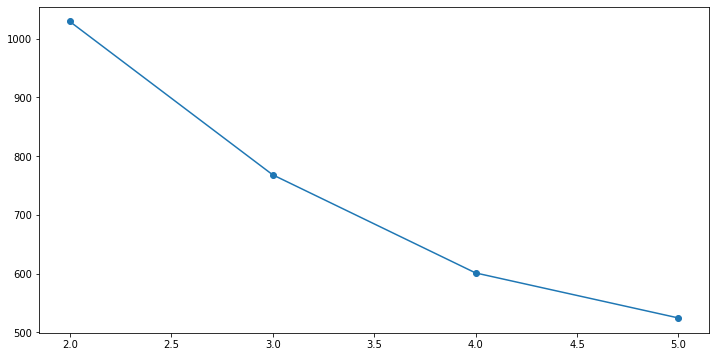

In [65]:
plt.figure(figsize=(12,6))
plt.plot( clusters_df.num_clusters, clusters_df.cluster_errors, marker = "o" )

In [72]:
# The elbow plot confirms our visual analysis that there are likely 3 or 4 good clusters
# Let us start with 4 clusters
cluster = KMeans( n_clusters = 4, init='random', random_state = 5)
cluster.fit(Proj_data_df)

KMeans(algorithm='auto', copy_x=True, init='random', max_iter=300, n_clusters=4,
       n_init=10, n_jobs=None, precompute_distances='auto', random_state=5,
       tol=0.0001, verbose=0)

In [73]:
centroids = cluster.cluster_centers_
centroids

array([[ 1.75787823, -0.54889255, -0.40809067, -0.09654806],
       [ 1.30234004,  1.13014267,  0.17932239, -0.07151431],
       [-3.23091896, -0.04155947, -0.06266032,  0.01710827],
       [-0.37698552, -0.40184011,  0.44114576,  0.19196627]])

# Use linear regression model on different clusters separately and print the coefficients of the models individually (10 points)

In [74]:
from sklearn import model_selection
from sklearn.linear_model import LinearRegression

x_train, x_test, y_train, y_test = model_selection.train_test_split(Proj_data_df, Y, test_size=0.3, random_state=5)

In [75]:
from sklearn import svm
clr = svm.SVR()  
clr.fit(x_train , y_train)

/Applications/anaconda3/lib/python3.6/site-packages/sklearn/svm/base.py:193: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


SVR(C=1.0, cache_size=200, coef0=0.0, degree=3, epsilon=0.1,
    gamma='auto_deprecated', kernel='rbf', max_iter=-1, shrinking=True,
    tol=0.001, verbose=False)

In [76]:
y_pred = clr.predict(x_test)

In [77]:
y_pred

array([28.41978254, 29.10652618, 27.80410897, 24.39009273, 18.49868523,
       23.08285354, 32.21798114, 26.01147167, 19.83916117, 25.33156508,
       23.82495818, 33.84860595, 25.54743478, 26.50139461, 32.5262605 ,
       14.69025873, 34.32667234, 34.57632299, 14.50198446, 34.55120237,
       28.06928299, 30.40841918, 18.49347106, 22.40924556, 15.73563256,
       13.114479  , 13.87511054, 31.89309905, 28.10278323, 14.96197365,
       17.65532044, 24.39771149, 25.34601873, 13.14323849, 19.02372911,
       13.85813497, 33.72911606, 29.69894101, 17.57667006, 24.32926873,
       31.33933778, 18.07380865, 24.86351297, 31.49650306, 14.03846157,
       23.24935342, 23.94139974, 26.25748248, 15.24898972, 16.39425455,
       23.85225624, 26.51801041, 19.70628903, 32.51099762, 21.87592467,
       18.70817444, 16.27082204, 28.10693794, 26.00854238, 24.26707348,
       21.79551706, 32.57435506, 16.80307264, 22.64748056, 24.93708692,
       24.22848088, 19.50829947, 24.86732988, 28.70630166, 18.70